<h1>Medical Image Segmentation AI Model</h1>

This code uses the dataset from Cybele

In developing the model I have used the MONAI Documentation continuously: https://docs.monai.io/en/stable/networks.html

Additionally I have used inspiration from MONAI's Tutorial Repository: https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/unet_segmentation_3d_ignite.ipynb

I have also used ChatGPT for help with errors and some debugging

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import torch
from torch import nn
import matplotlib.pyplot as plt
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd, Resized, RandCoarseDropoutd, RandZoomd, RandShiftIntensityd,
    RandCropByPosNegLabeld, RandRotate90d, RandFlipd, RandGaussianNoised, CropForegroundd, Rand3DElasticd,
    ToTensord, EnsureTyped, Transform, Spacingd, SpatialPadd, RandSpatialCropd, RandAdjustContrastd, RandAffined
)
from monai.networks.nets import SegResNet, UNet, AttentionUnet
from monai.losses import DiceFocalLoss, DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

<h3>Loading data</h3>

In [ ]:
# Use of ChatGPT for help with loading data
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"

case_dirs = sorted(glob.glob(os.path.join(base_dir, "*")))
data = []

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir) 
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(data)} samples.")
print(data[0])

# Split the data into training and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)  # 80% train, 20% validation

Found 130 samples.
{'image': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz', 'label': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz'}


<h3>Transformations</h3>

In [ ]:
# Transforms for data preprocessing
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,1.0), mode=("bilinear", "nearest")), #changed to cube
    NormalizeIntensityd(keys=["image"]),
    CropForegroundd(keys=["image", "label"], source_key="image"), # Crop out parts with only background
    SpatialPadd(keys=["image", "label"], spatial_size=[192, 192, 64]), # Ensure at least as big sa crop
    RandCropByPosNegLabeld( # Crop instead of resize for medical consistency
        keys=["image", "label"],
        label_key="label",
        spatial_size=(192, 192, 64), # Smaller as new model is computationally expensive
        pos=2, # force some positive crops
        neg=1, # allow negative crops
        num_samples=3, # number of patches per volume
        image_key="image",
    ),
    # Data augmentation (More of light, less of heavy)
    RandRotate90d(keys=["image", "label"], prob=0.2),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0]),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[1]),
    RandGaussianNoised(keys=["image"], prob=0.1),
    RandAffined(keys=["image", "label"], rotate_range=(0.1, 0.1, 0.1), scale_range=(0.1, 0.1, 0.1), prob=0.3),
    Rand3DElasticd(keys=["image", "label"], sigma_range=(2,5), magnitude_range=(20,80), prob=0.1), # Less warping
    RandAdjustContrastd(keys=["image"], prob=0.2, gamma=(0.7, 1.5)),
    RandZoomd(keys=["image", "label"], min_zoom=0.9, max_zoom=1.1, prob=0.2),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.2),
    RandCoarseDropoutd(keys=["image"], holes=3, spatial_size=(12, 12, 4), prob=0.1), #smaller dropout 
    # Final transformations
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,1.0), mode=("bilinear", "nearest")), # Same spacing as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Dataset and DataLoader
train_dataset = Dataset(data=train_data, transform=train_transforms) # Loading and transforming data
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=8, persistent_workers=True, pin_memory=True) # Loads 2 batches in parallel

val_dataset = Dataset(data=val_data, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True) #batch size 1 allows different sized images


monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.


<h3>Building the Model</h3>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

# Define the model (MONAIs SegResNet: based on 3D MRI brain tumor segmentation using autoencoder regularization)
    # Generally good for large datasets, so augmentation is important here!
model = SegResNet( # Change to SegResNet -> stronger model, for 3D MRI brain tumor segmentation, better skips (like ResNet)
    spatial_dims=3, # 3D model (volumetric MRI data)
    in_channels=1, # Single-channel input (T2 MRI image -> greyscale)
    out_channels=3, # 3 output channels: (background, tumor1, tumor2)
    init_filters=32, # filters in first conv block, still 32 as in previous attentinUnet model
    blocks_down=[1, 2, 2, 4], # 4 Encoder (down path) levels with 1, 2, 2, 4 residual blocks (each level reduces spatial resolution and increases channels)
    blocks_up=[1, 1, 1], # 3 Decoder (up path) levels iwth 1 residual block each (feature maps upsampeled and merged)
    dropout_prob=0.2 # Dropout for better generalization
).to(device)

# Loss function
loss_function = DiceFocalLoss(include_background=True, to_onehot_y=True, softmax=True, gamma=2.0) # Back to DiceFocalLoss; good as tumors are small (from EDA), focus on hard examples.

# Optimizer and scheduler
# Change to AdamW to try lr scheduler (not regular Adam as we want L2 regularization)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5) # wd to 1e-5 (enough to not overfit) isntead of 1e-2 as we have a small dataset and small tumors
scheduler = CosineAnnealingLR(optimizer, T_max=250) # First slow lr decay, then fast, then slower again (smooth lr change)

# Dice metric for evaluation
train_dice_metric = DiceMetric(include_background=True, reduction="mean")
val_dice_metric = DiceMetric(include_background=True, reduction="mean")

# Automatic Mixed Precicion (AMP) -> reduced memory and training time
scaler = GradScaler()

Using device: cuda


<h3>Early stopping</h3>

In [6]:
class EarlyStopping:
    def __init__(self, patience=20, verbose=True, delta=0.0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, val_dice, epoch):
        score = val_dice

        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0


early_stopping = EarlyStopping(patience=50, verbose=True, delta=0.001)

<h3>Training the Model</h3>

In [ ]:
num_epochs = 250
best_val_dice = 0.0
train_losses, train_dices, val_dices = [], [], []

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0.0
    epoch_train_dice = 0.0
    train_dice_metric.reset()

    for batch_data in train_loader:
        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad() # clear old gradients
        with autocast(device_type="cuda"): # Forward pass in mixed precision
            outputs = model(images)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward() # Compute gradients with b-pass with scaled loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Limit exploding gradients
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        outputs = torch.softmax(outputs, dim=1) # softmax for multiclass
        preds = torch.argmax(outputs, dim=1, keepdim=True) # converting to a class
        train_dice_metric(preds, labels)

    epoch_loss /= len(train_loader)
    epoch_train_dice = train_dice_metric.aggregate().item()
    scheduler.step()

    # Validation phase
    model.eval()
    epoch_val_dice = 0.0
    val_dice_metric.reset()
    with torch.no_grad(): # disable gradient computation
        for batch_data in val_loader:
            images = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)
            with autocast(device_type="cuda"):
                outputs = sliding_window_inference( # to handle 3d volume and have correct output shape
                    images,
                    roi_size=[192, 192, 64],
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.25 # for smoother output
                )
            outputs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1, keepdim=True)
            val_dice_metric(preds, labels)

    epoch_val_dice = val_dice_metric.aggregate().item()

    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model with Val Dice:", best_val_dice)

    train_losses.append(epoch_loss)
    train_dices.append(epoch_train_dice)
    val_dices.append(epoch_val_dice)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Training Loss: {epoch_loss:.4f}, Training Dice: {epoch_train_dice:.4f}")
    print(f"  Validation Dice: {epoch_val_dice:.4f}")

    # Early stopping check
    early_stopping(epoch_val_dice, epoch)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}. Best epoch was {early_stopping.best_epoch+1}.")
        break

    # if epoch % 10 == 0:
    #     slice_idx = 32 
    #     plt.figure(figsize=(12,4))
    #     plt.subplot(1, 3, 1)
    #     plt.imshow(images[0, 0, :, :, slice_idx].cpu(), cmap='gray')
    #     plt.title('Input Image')
        
    #     plt.subplot(1, 3, 2)
    #     plt.imshow(labels[0, 0, :, :, slice_idx].cpu(), cmap='gray')
    #     plt.title('Ground Truth')
        
    #     plt.subplot(1, 3, 3)
    #     plt.imshow(preds[0, 0, :, :, slice_idx].cpu(), cmap='gray')
    #     plt.title('Prediction')

    #     plt.tight_layout()
    #     plt.show()
        

Epoch 1/250
  Training Loss: 0.7534, Training Dice: 0.0003
  Validation Dice: 0.0000
Epoch 2/250
  Training Loss: 0.7182, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 1/50
Epoch 3/250
  Training Loss: 0.7013, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 2/50
Epoch 4/250
  Training Loss: 0.6899, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 3/50
Epoch 5/250
  Training Loss: 0.6801, Training Dice: 0.0000
  Validation Dice: 0.0000
EarlyStopping counter: 4/50
Epoch 6/250
  Training Loss: 0.6726, Training Dice: 0.0009
  Validation Dice: 0.0000
EarlyStopping counter: 5/50
Saved new best model with Val Dice: 0.09511943906545639
Epoch 7/250
  Training Loss: 0.6652, Training Dice: 0.0908
  Validation Dice: 0.0951
Saved new best model with Val Dice: 0.11246147751808167
Epoch 8/250
  Training Loss: 0.6556, Training Dice: 0.1012
  Validation Dice: 0.1125
Epoch 9/250
  Training Loss: 0.6512, Training Dice: 0.0985
  Validat

<h3>Visualization of Training</h3>

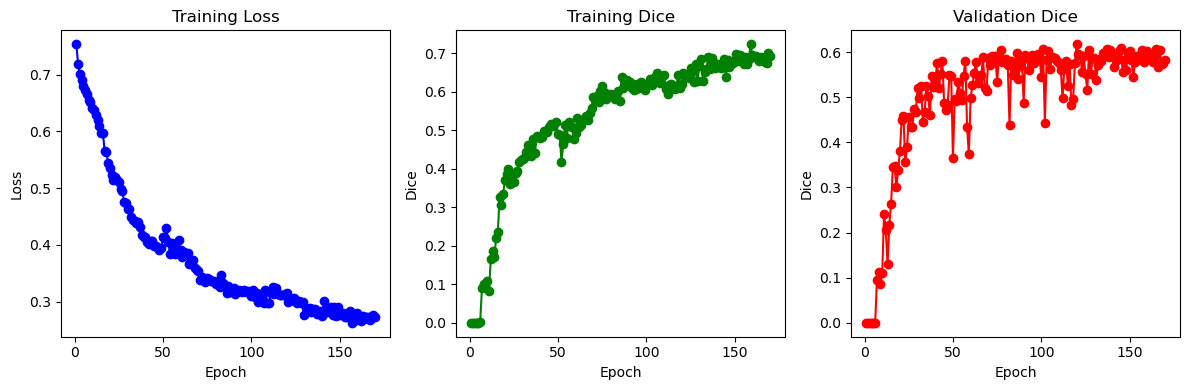

In [ ]:
# Use of ChatGPT for help with plotting
epochs = range(1, 170+1)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, 'b-o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, train_dices, 'g-o')
plt.title('Training Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.subplot(1,3,3)
plt.plot(epochs, val_dices, 'r-o')
plt.title('Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.tight_layout()
plt.show()

<h3>Evaluation</h3>

In [ ]:
test_base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/test" 

test_case_dirs = sorted(glob.glob(os.path.join(test_base_dir, "*")))
test_data = []

for case_dir in test_case_dirs:
    case_id = os.path.basename(case_dir)
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        test_data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(test_data)} test samples.")

Found 20 test samples.


In [ ]:
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,1.0), mode=("bilinear", "nearest")), # Same as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"], track_meta=True),
    EnsureTyped(keys=["image", "label"], track_meta=True),
])

# Create the test dataset and DataLoader
test_dataset = Dataset(data=test_data, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True) # No shuffling for evaluation

In [ ]:
# Load the model and set it to evaluation mode
model = SegResNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    init_filters=32,
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    dropout_prob=0.2
).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Initialize same lossfunction and metric for Dice score
loss_function = DiceFocalLoss(include_background=True, to_onehot_y=True, softmax=True, gamma=2.0)
test_dice_metric = DiceMetric(include_background=True, reduction="mean")

test_loss_total = 0.0
test_dice_metric.reset()

with torch.no_grad():
    for i, test_batch in enumerate(test_loader):
        images = test_batch["image"].to(device)
        labels = test_batch["label"].to(device) 

        affine = images.meta["affine"].cpu().numpy() # getting original affine, as voxel spacing will be normalized
        if affine.shape == (1, 4, 4):
            affine = affine[0]

        with autocast(device_type="cuda"):
            outputs = sliding_window_inference(
                images,
                roi_size=(192, 192, 64),
                sw_batch_size=1,
                predictor=model,
                overlap=0.25
            )

        loss = loss_function(outputs, labels)
        test_loss_total += loss.item()

        outputs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1, keepdim=True)
        test_dice_metric(preds, labels)

        # Save Predictions
        save_dir = os.path.join(os.getcwd(), "test_predictions_v12")
        os.makedirs(save_dir, exist_ok=True)
        pred_np = preds.squeeze().cpu().numpy().astype(np.uint8)
        case_id = os.path.basename(test_case_dirs[i])
        save_path = os.path.join(save_dir, f"{case_id}_prediction.nii.gz")
        nib.save(nib.Nifti1Image(pred_np, affine), save_path)

# Average over all test samples
avg_test_loss = test_loss_total / len(test_loader)
avg_test_dice = test_dice_metric.aggregate().item()

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Dice: {avg_test_dice:.4f}")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Test Loss: 0.3065
Test Dice: 0.6083


<h3>Visualization</h3>

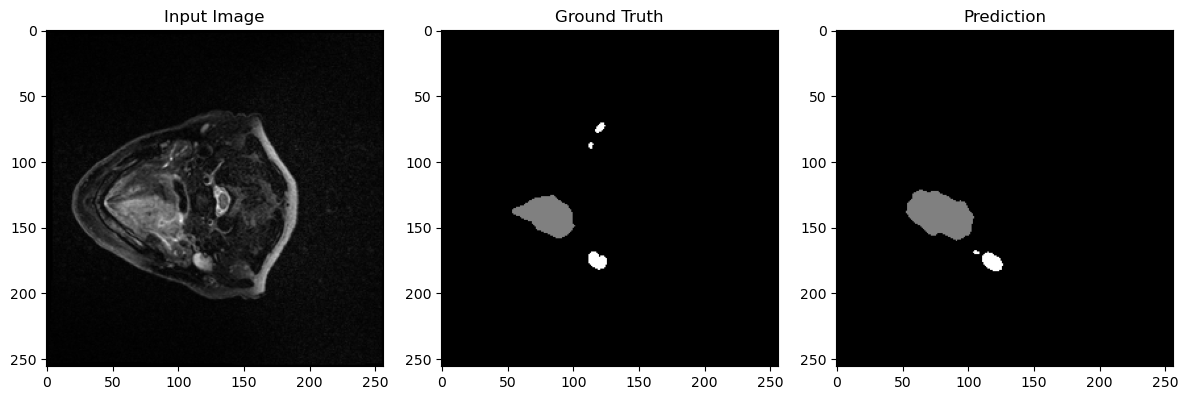

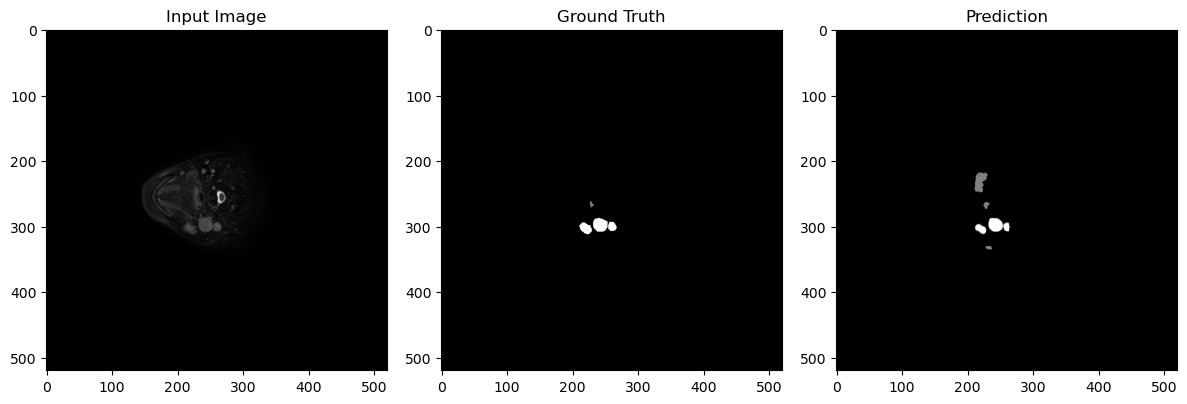

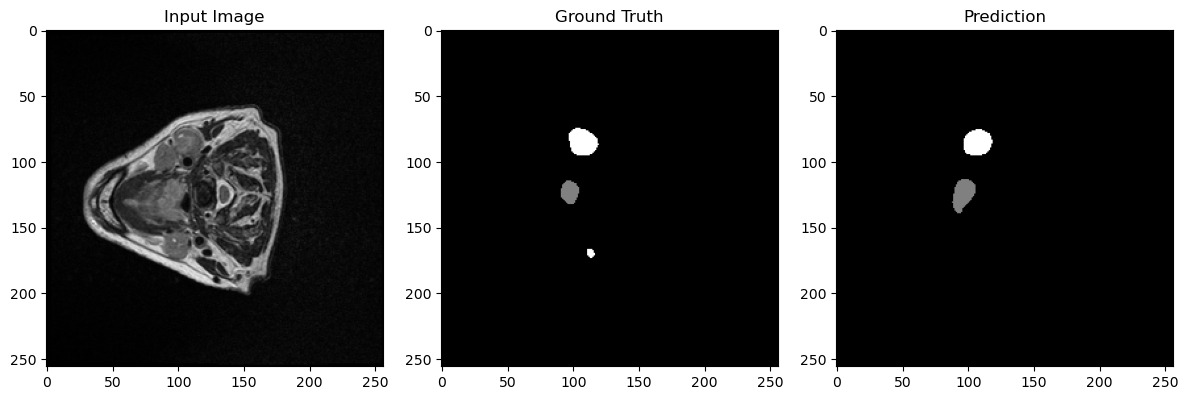

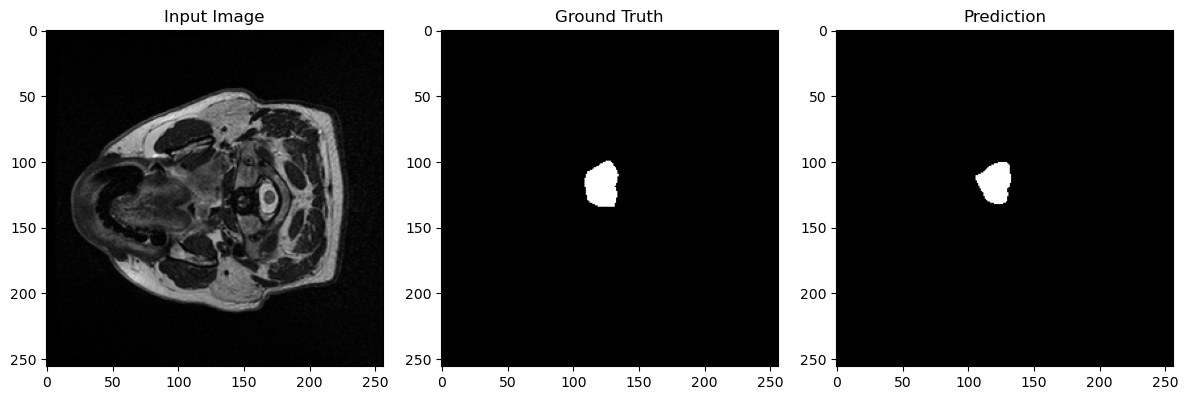

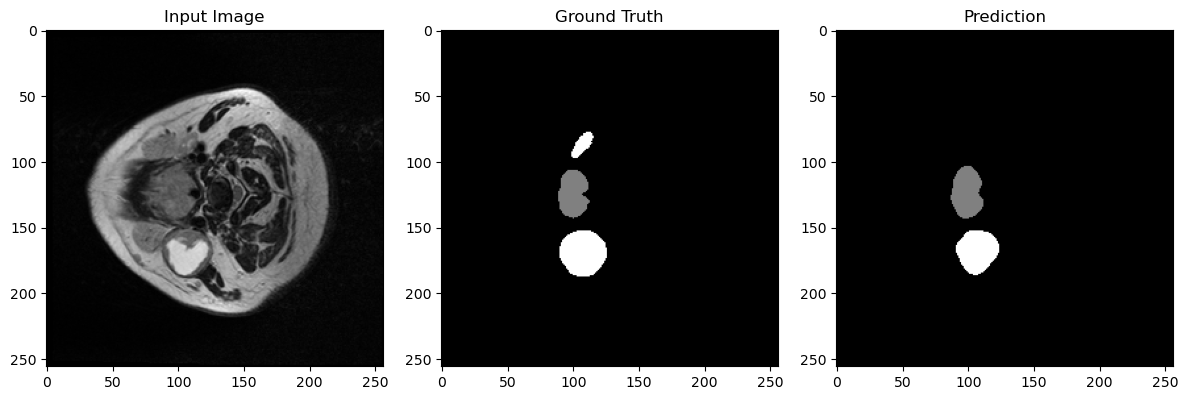

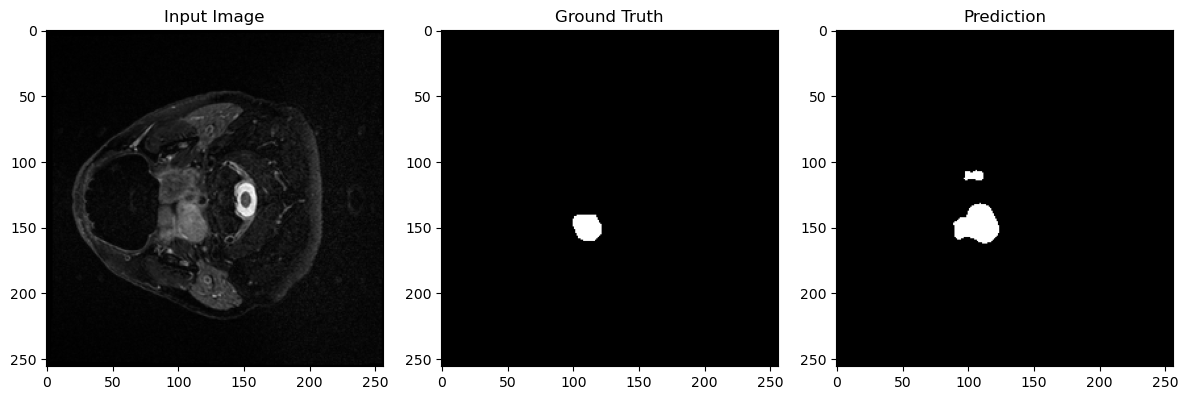

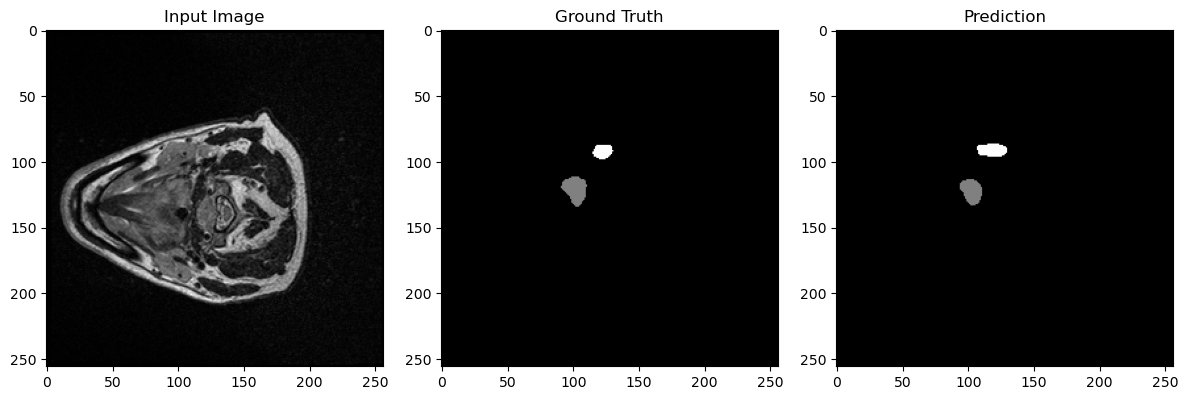

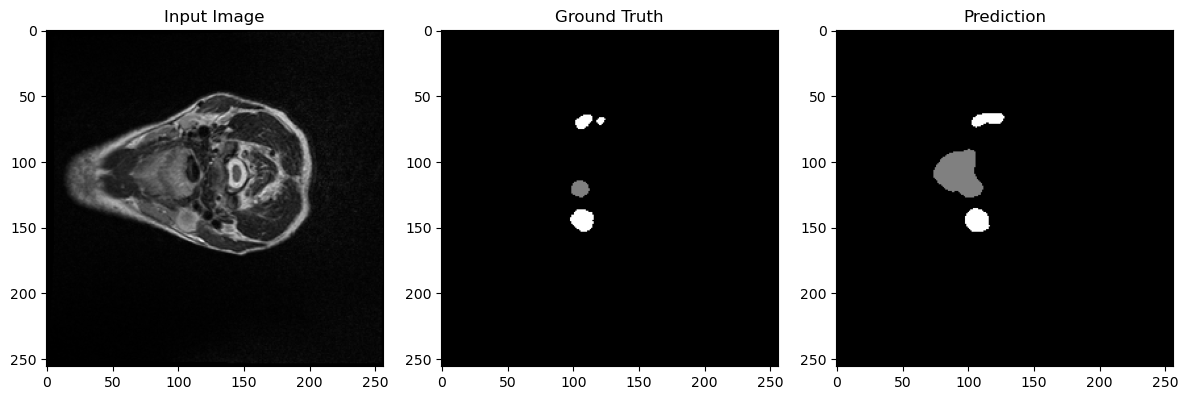

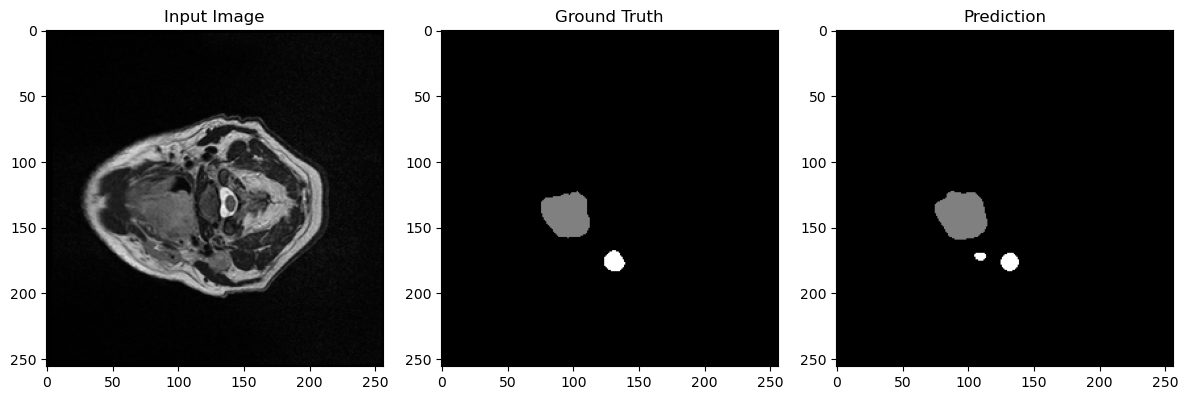

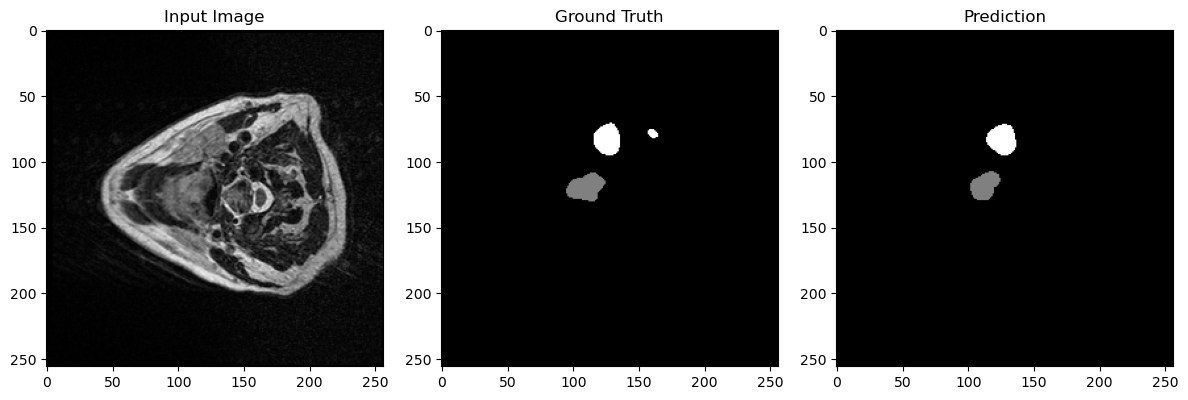

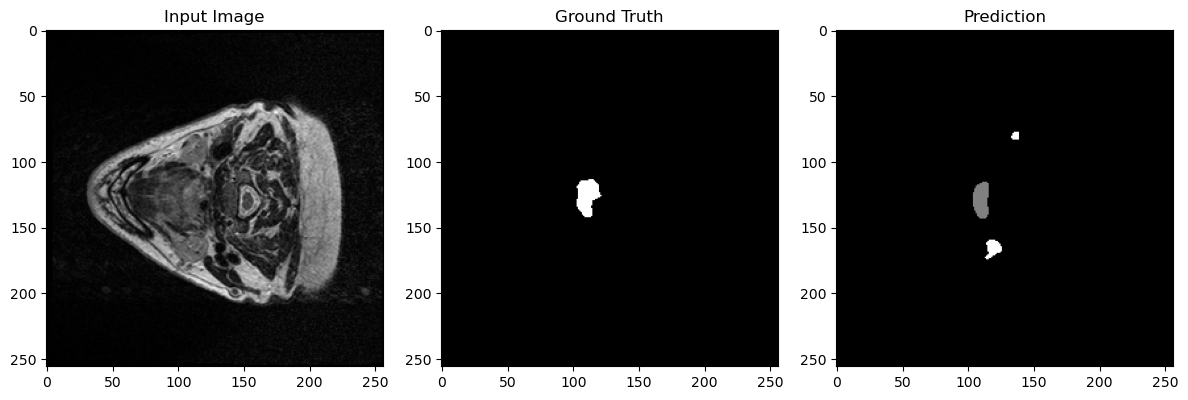

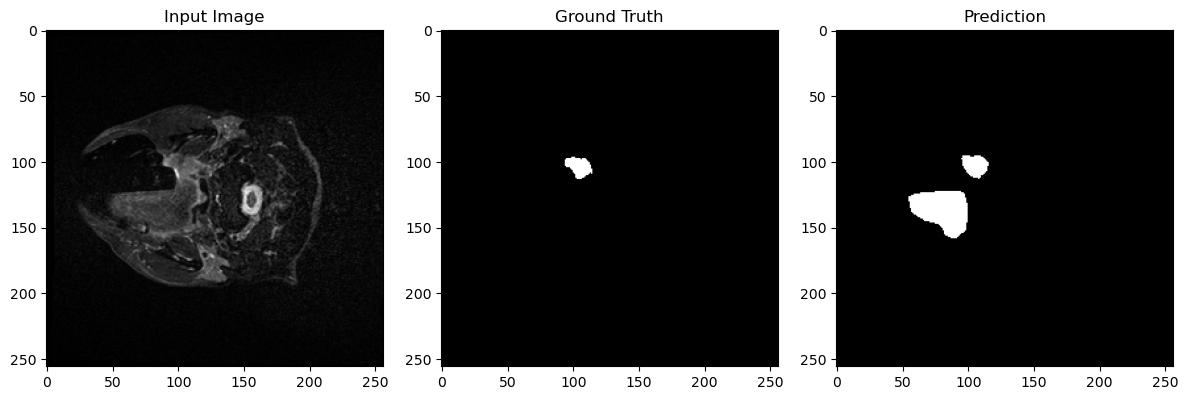

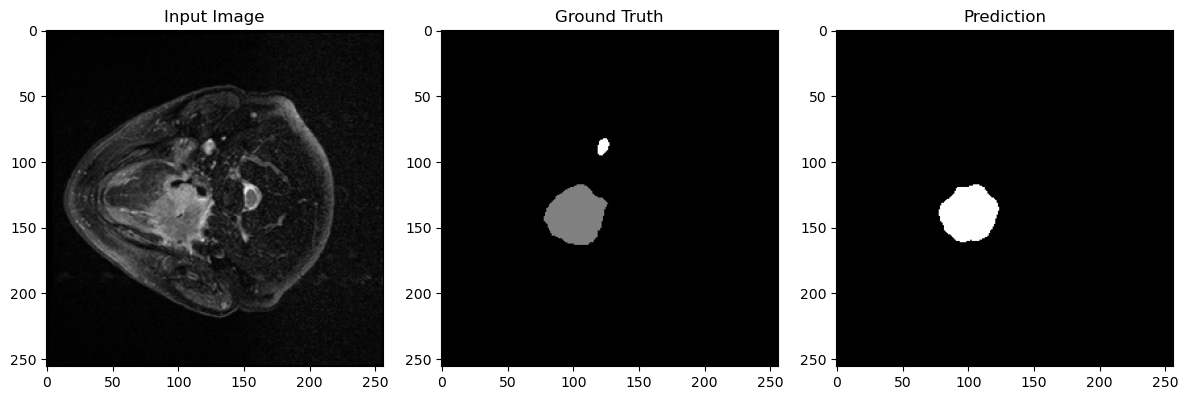

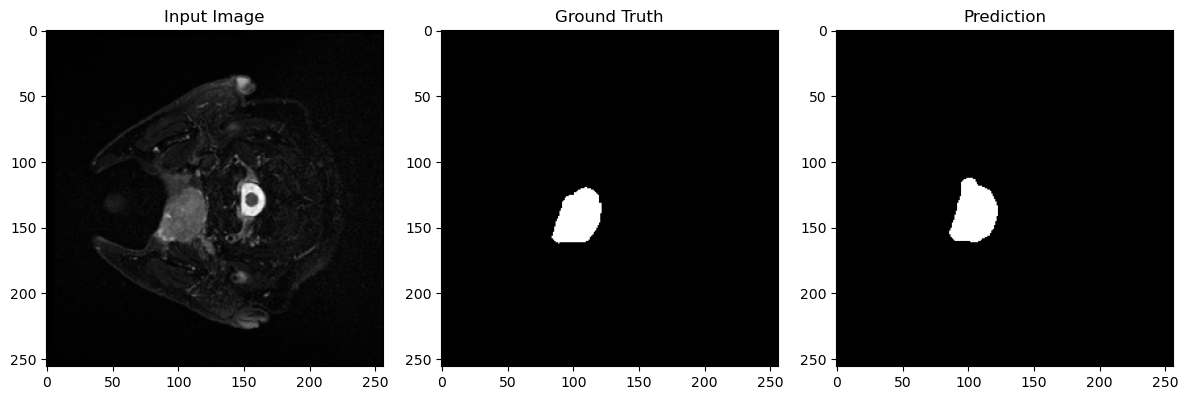

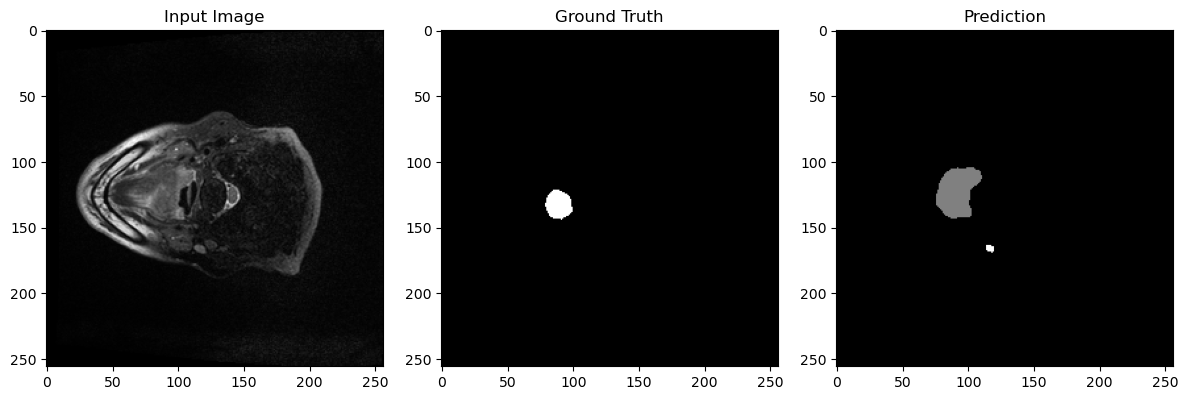

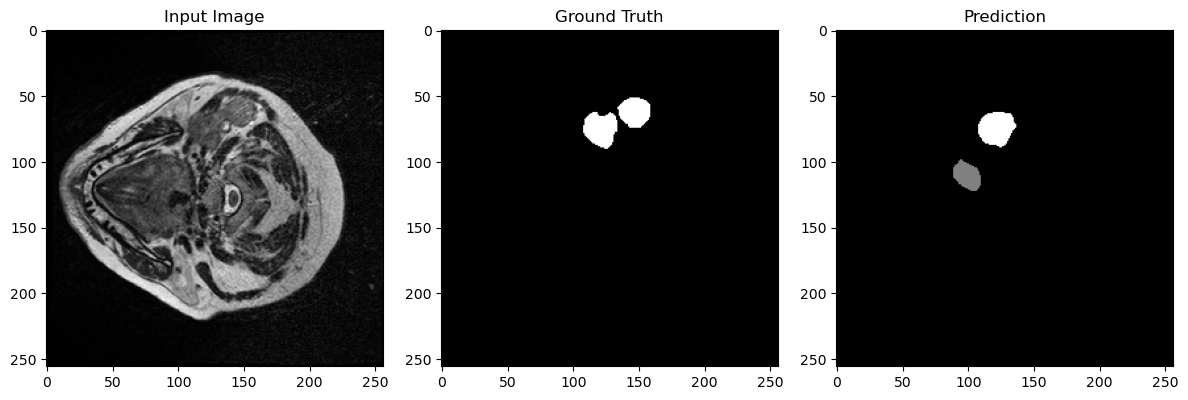

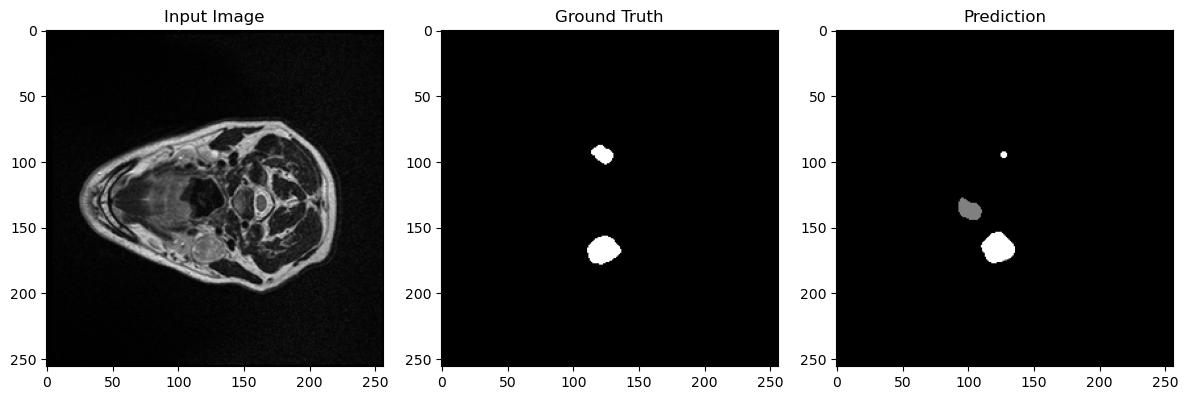

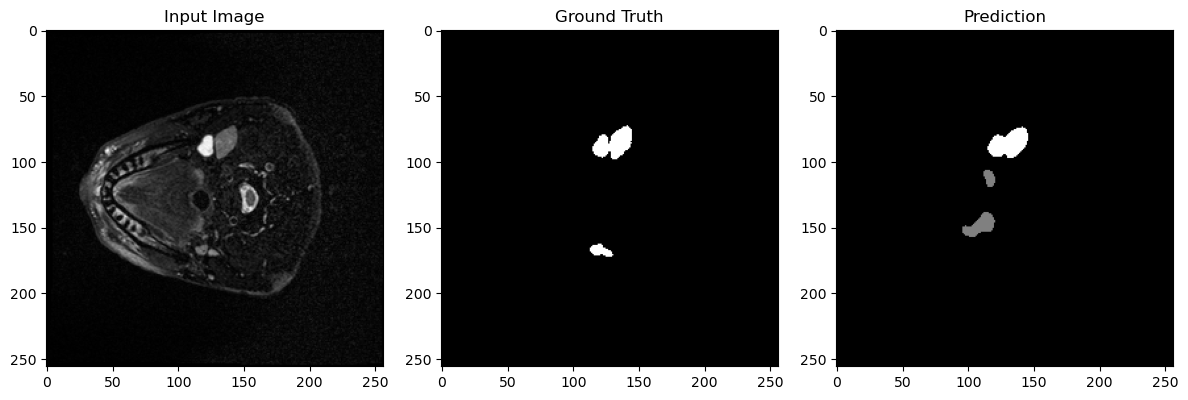

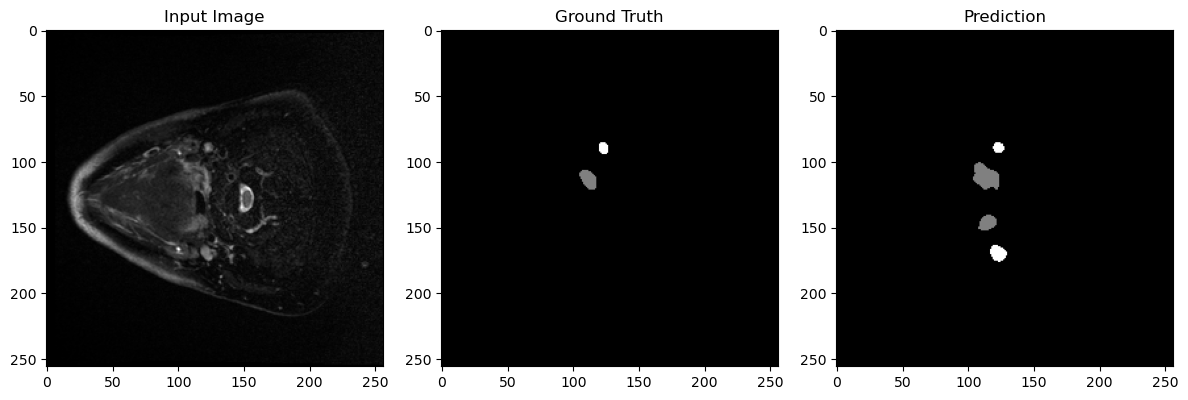

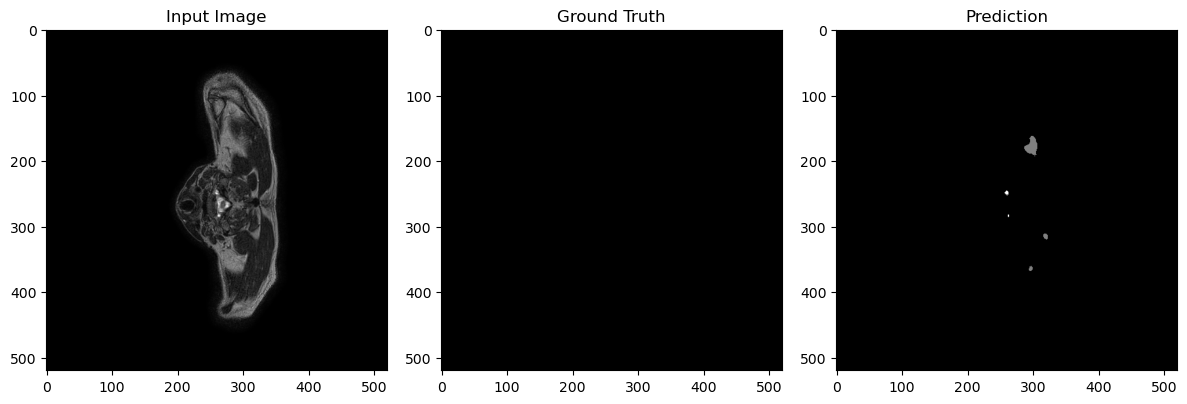

In [ ]:
# Ensure model is in eval mode
model.eval()

# Loop through test dataset
for batch_data in test_loader:
    images = batch_data["image"].to(device)
    labels = batch_data["label"].to(device)

    with torch.no_grad(): # Inference with sliding window
        outputs = sliding_window_inference(
            images, roi_size=(256, 256, 64), sw_batch_size=1, predictor=model, overlap=0.25
        )
        outputs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1, keepdim=True)

    # Move everything to CPU
    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    # Remove batch and channel dimensions
    image = images[0, 0]
    label = labels[0, 0]
    pred = preds[0, 0]  

    # slice with most tumor
    tumor_sums = pred.numpy().sum(axis=(0, 1))
    slice_idx = tumor_sums.argmax()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.title('Input Image')

    plt.subplot(1, 3, 2)
    plt.imshow(label[:, :, slice_idx], cmap='gray')
    plt.title('Ground Truth')

    plt.subplot(1, 3, 3)
    plt.imshow(pred[:, :, slice_idx], cmap='gray')
    plt.title('Prediction')

    plt.tight_layout()
    plt.show()